### Data Wrangling : Products

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
from pathlib import Path

# Load dataset
data_path = Path("data/raw/products.csv")
if not data_path.exists():
    data_path = Path("../data/raw/products.csv")  

df = pd.read_csv(data_path)
df.head()
                               

,product_id,product_name,category,cost_price,selling_price,stock_available
0,P001,Cotton Kurta,Apparel,8.0,19.99,132
1,P002,Formal Shirt,Apparel,12.0,34.99,465
2,P003,Denim Jeans,Apparel,18.0,54.99,378
3,P004,Ethnic Saree,Apparel,22.0,79.99,300
4,P005,Winter Jacket,Apparel,35.0,99.99,136


In [10]:
# Shape of dataset
df.shape

(40, 6)

In [13]:
# Statistical summary 
df.describe()

,cost_price,selling_price,stock_available
count,40.000000,40.000000,40.000000
mean,21.925000,55.390250,268.650000
std,23.178944,48.717051,135.759506
min,2.000000,6.990000,50.000000
25%,8.000000,24.490000,147.250000
50%,15.000000,39.990000,273.500000
75%,22.000000,61.240000,375.000000
max,95.000000,210.000000,496.000000


In [14]:
# Check data types
df.dtypes

product_id             str
product_name           str
category               str
cost_price         float64
selling_price      float64
stock_available      int64
dtype: object

In [15]:
# Null values
df.isnull().sum()

product_id         0
product_name       0
category           0
cost_price         0
selling_price      0
stock_available    0
dtype: int64

In [19]:
# Duplicated values
df.duplicated().sum()

np.int64(0)

In [21]:
# Data validation for cost_price and selling_price
errors = df[df['selling_price'] >= df['cost_price'] ]
print(len(errors))

40


In [28]:
# Validation for stock available
avail = df['stock_available']<0
print(len(avail))

40


In [23]:
# Profit column
df['profit'] = df['selling_price'] - df['cost_price']
df['profit'].head()

0    11.99
1    22.99
2    36.99
3    57.99
4    64.99
Name: profit, dtype: float64

In [24]:
# Profit margin column 
df['margin'] = df['profit']/df['selling_price']
df['margin'].head()

0    0.599800
1    0.657045
2    0.672668
3    0.724966
4    0.649965
Name: margin, dtype: float64

In [25]:
# Stock value at cost
df['inventory_cost'] = df['cost_price']*df['stock_available']
df['inventory_cost'].head()

0    1056.0
1    5580.0
2    6804.0
3    6600.0
4    4760.0
Name: inventory_cost, dtype: float64

In [26]:
# Potential revenue 
df['inventory_revenue'] = df['selling_price']*df['stock_available']
df['inventory_revenue'].head()

0     2638.68
1    16270.35
2    20786.22
3    23997.00
4    13598.64
Name: inventory_revenue, dtype: float64

In [36]:
# Inventory Risk
# Thresholds (top 25% stock, bottom 25% margin)
stock_threshold = df['stock_available'].quantile(0.75)
margin_threshold = df['margin'].quantile(0.25)

df['inventory_risk'] = (
    (df['stock_available'] > stock_threshold) &
    (df['margin'] < margin_threshold)
)
df['inventory_risk'].head()

0    False
1    False
2    False
3    False
4    False
Name: inventory_risk, dtype: bool

In [35]:
# Add labels
df['inventory_risk_label'] = df['inventory_risk'].map({
    True: 'High Risk',
    False: 'Normal'
})
df['inventory_risk_label'].head()

0    Normal
1    Normal
2    Normal
3    Normal
4    Normal
Name: inventory_risk_label, dtype: str

In [34]:
# Price bucket
df['price_bucket'] = pd.qcut(
    df['selling_price'],
    q=3,
    labels=['Low Price', 'Mid Price', 'High Price']
)
df['price_bucket'].head()

0     Low Price
1     Mid Price
2     Mid Price
3    High Price
4    High Price
Name: price_bucket, dtype: category
Categories (3, str): ['Low Price' < 'Mid Price' < 'High Price']

### Insights

In [37]:
# Q1. How many risky products?
df['inventory_risk_label'].value_counts()

inventory_risk_label
Normal       37
High Risk     3
Name: count, dtype: int64

In [38]:
# Q2. Money stuck in risky inventory
df[df['inventory_risk']]['inventory_cost'].sum()

np.float64(101770.0)

In [39]:
# Q3. Avg margin by price bucket
df.groupby('price_bucket')['margin'].mean()

price_bucket
Low Price     0.674881
Mid Price     0.636866
High Price    0.594643
Name: margin, dtype: float64

C:\Users\kaurs\AppData\Local\Temp\ipykernel_4668\3158883205.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_profit.index, y=category_profit.values, palette='Blues_r')


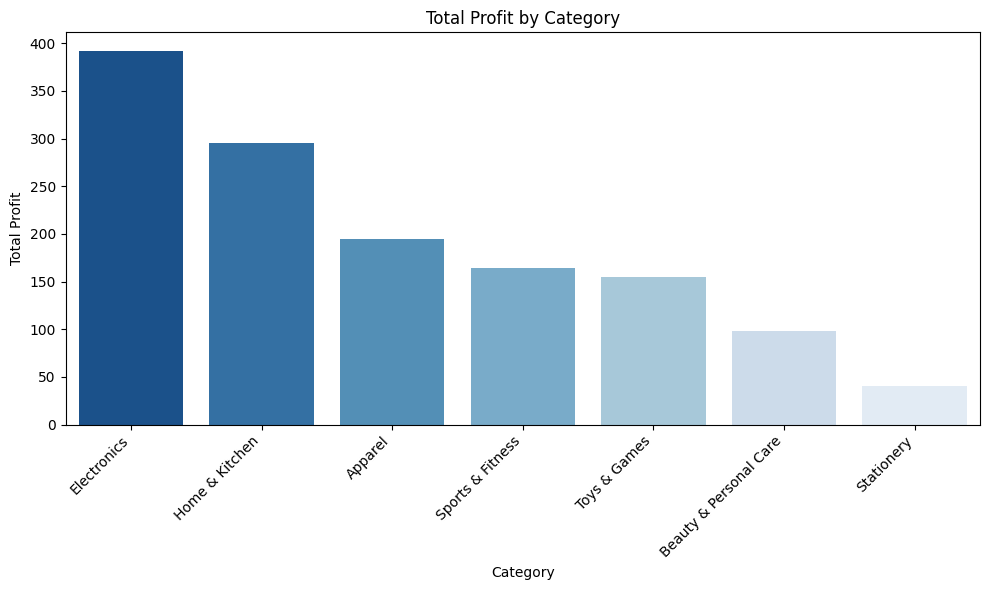

In [49]:
# Q4. Which category contributes most to overall profit?
category_profit = df.groupby('category')['profit'].sum().sort_values(ascending=False)
# print(category_profit)

plt.figure(figsize=(10, 6))
sns.barplot(x=category_profit.index, y=category_profit.values, palette='Blues_r')
plt.title('Total Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

C:\Users\kaurs\AppData\Local\Temp\ipykernel_4668\114933281.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_profit.index, y=avg_profit.values, palette='Greens_r')


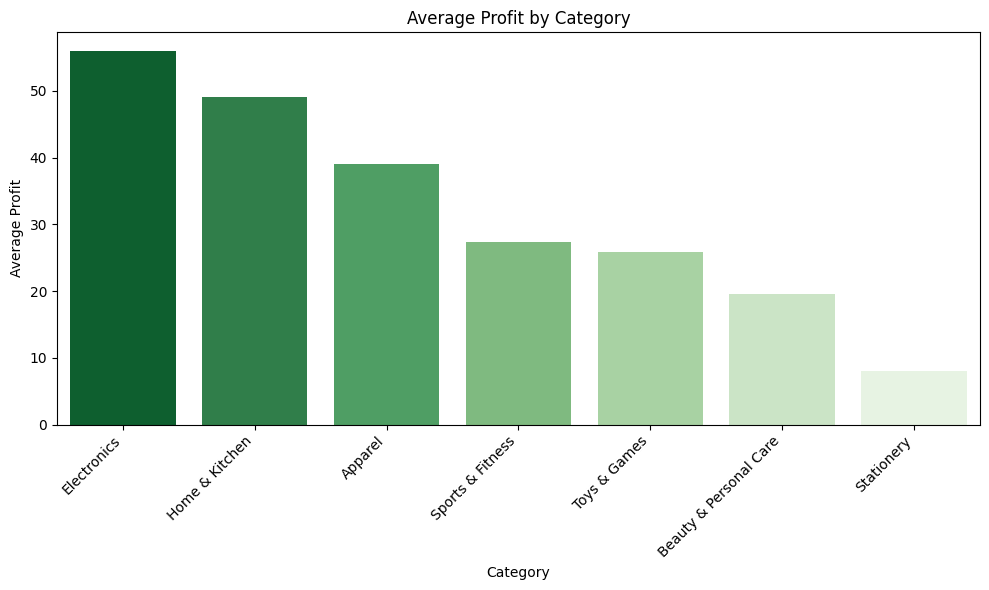

In [51]:
# Q5. Which category has more profitable products on average?
avg_profit = df.groupby('category')['profit'].mean().sort_values(ascending=False)
# print(avg_profit)

plt.figure(figsize=(10, 6))
sns.barplot(x=avg_profit.index, y=avg_profit.values, palette='Greens_r')
plt.title('Average Profit by Category')
plt.xlabel('Category')
plt.ylabel('Average Profit')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

C:\Users\kaurs\AppData\Local\Temp\ipykernel_4668\3641095601.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_margin.index, y=avg_margin.values, palette='Oranges_r')


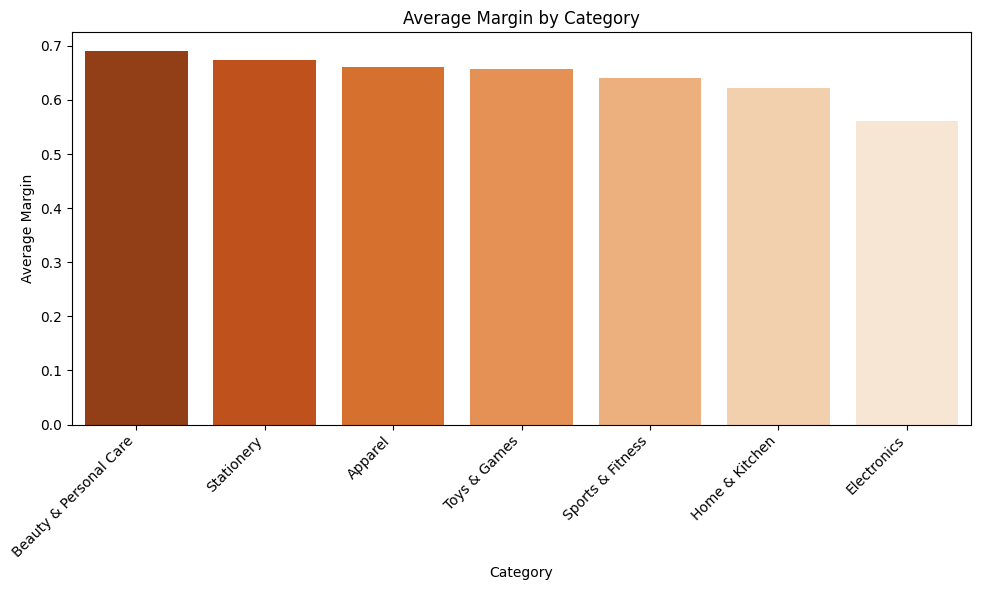

In [53]:
# Q6. Which category has better pricing power?
avg_margin = df.groupby('category')['margin'].mean().sort_values(ascending=False)
# print(avg_margin)

plt.figure(figsize=(10, 6))
sns.barplot(x=avg_margin.index, y=avg_margin.values, palette='Oranges_r')
plt.title('Average Margin by Category')
plt.xlabel('Category')
plt.ylabel('Average Margin')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

C:\Users\kaurs\AppData\Local\Temp\ipykernel_4668\1379828992.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=inventory_value.index, y=inventory_value.values, palette='Purples_r')


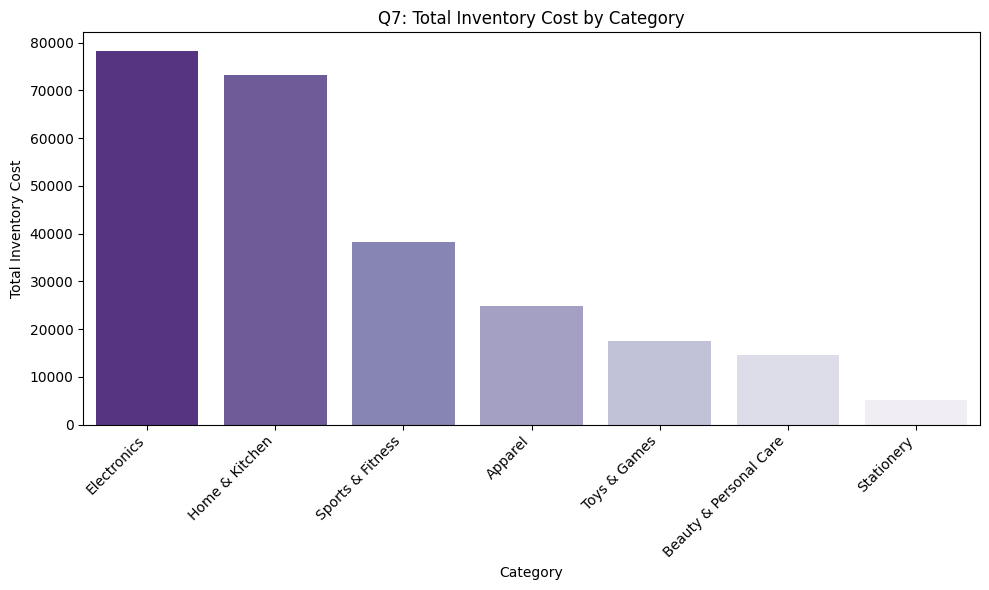

In [55]:
# Q7. Where is most capital invested?
inventory_value = df.groupby('category')['inventory_cost'].sum().sort_values(ascending=False)
# print(inventory_value)

plt.figure(figsize=(10, 6))
sns.barplot(x=inventory_value.index, y=inventory_value.values, palette='Purples_r')
plt.title('Q7: Total Inventory Cost by Category')
plt.xlabel('Category')
plt.ylabel('Total Inventory Cost')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Electronics gives the highest total profit but also requires the most investment in inventory, so it is a capital-heavy category. Beauty & Personal Care has the highest average margins, which means it earns better profit per product. On the other hand, Stationery gives the least profit, so it may not be performing well and needs further review.